# 07 — Loss Function Sweep (Sweep A)

New baseline standard (EMA + protein-size-weighted loss, 4/4/4 rounds, multi-agg,
query features off) with `pearson_weight` swept over 0, 0.3, 0.5, 0.8, 1.0 for both
architectures. See `sweeps/phase_a_loss_weight.yaml` for the run definitions.

Message-passing aggregation (notebook 08, Sweep B) and query features
(notebook 10, Sweep C) are unchanged from prior decisions — no new runs for those.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png', 'distance_parity_hexbin.png'), so the
    actual filename is built per-run from run['model_type'] — passing a
    bare 'parity_hexbin.png' here is deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['model_type']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title_prefix, metrics):
    """1-row x 2-col grouped bar chart: one chart per model type.

    metrics: list of (column_name, color) tuples.
    """
    if df.empty:
        print("No data to plot.")
        return
    model_types = ["Attention", "Distance"]
    fig, axes = plt.subplots(1, len(model_types), figsize=(14, 5), sharey=False)
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")
    n_metrics = len(metrics)
    total_width = 0.7
    bar_w = total_width / n_metrics
    for ax, model_type in zip(axes, model_types):
        sub = df[df["Model"] == model_type].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        x = range(len(sub))
        for i, (metric, color) in enumerate(metrics):
            if metric not in sub.columns or sub[metric].isna().all():
                continue
            offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
            bars = ax.bar(offsets, sub[metric], width=bar_w, color=color, label=metric, zorder=3)
            ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
        ax.set_title(model_type, fontsize=12)
        ax.set_xlabel(sub.columns[2] if len(sub.columns) > 2 else "Run")
        ax.set_xticks(list(x))
        ax.set_xticklabels(sub["Run"].tolist(), fontsize=9, rotation=30, ha="right")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

PHASE = "phase_a"  # <- set to this phase's folder name

# Baseline symlinks (see Section 7 of the previous winning phase notebook).
BASELINE_CKPT = {
    "attention": CKPT_ROOT / "baseline_attention",
    "distance":  CKPT_ROOT / "baseline_distance",
}

# One dict per run in this phase. `suffix` must match the sweep YAML's
# `suffix:` for that run.
SUFFIXES = ["pw00", "pw03", "pw05", "pw08", "pw10"]

RUNS = [
    dict(label=f"{model.capitalize()} — {suffix}", model_type=model, suffix=suffix,
         plot_dir=EVAL_ROOT/PHASE/f"{model}_{suffix}", ckpt_dir=CKPT_ROOT/PHASE/f"{model}_{suffix}")
    for model in ["attention", "distance"]
    for suffix in SUFFIXES
]

print(f"{'Run':<22}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 42)
for r in RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "metrics.csv").exists()
    print(f"{r['label']:<22}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                      Plots   Metrics
------------------------------------------
Attention — pw00           yes       yes
Attention — pw03           yes       yes
Attention — pw05           yes       yes
Attention — pw08           yes       yes
Attention — pw10           yes       yes
Distance — pw00            yes       yes
Distance — pw03            yes       yes
Distance — pw05            yes       yes
Distance — pw08            yes       yes
Distance — pw10            yes       yes


## 2. Hexbin + Sorted Predictions
Fastest visual read: hexbin shows overall density/compression, sorted-prediction
shows behavior at the ESP extremes.

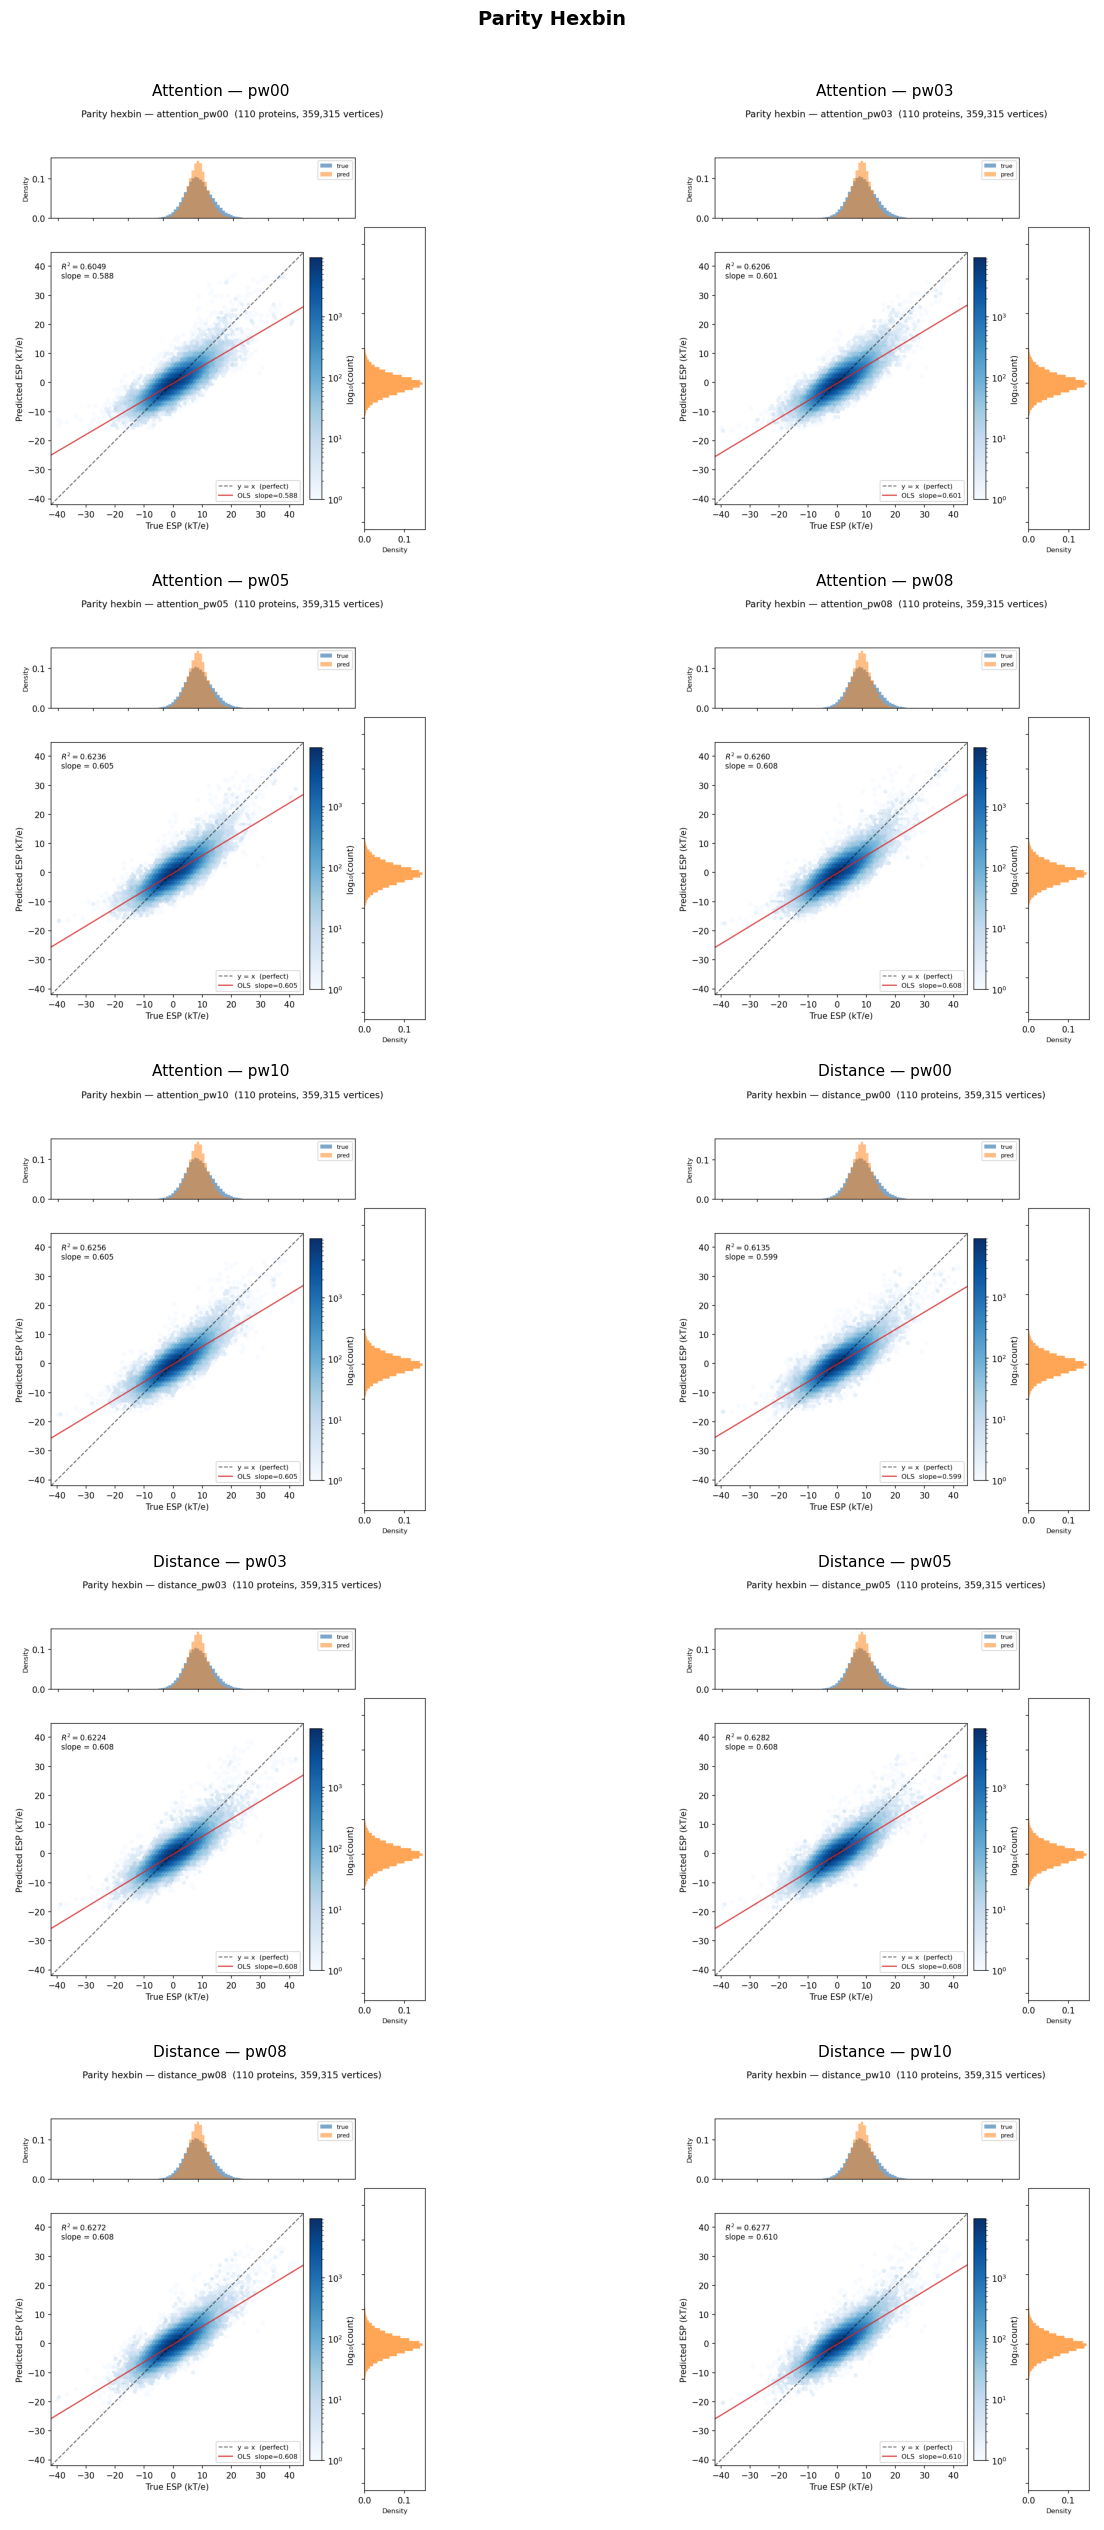

In [3]:
show_png_grid(RUNS, "parity_hexbin.png", "Parity Hexbin", ncols=2)

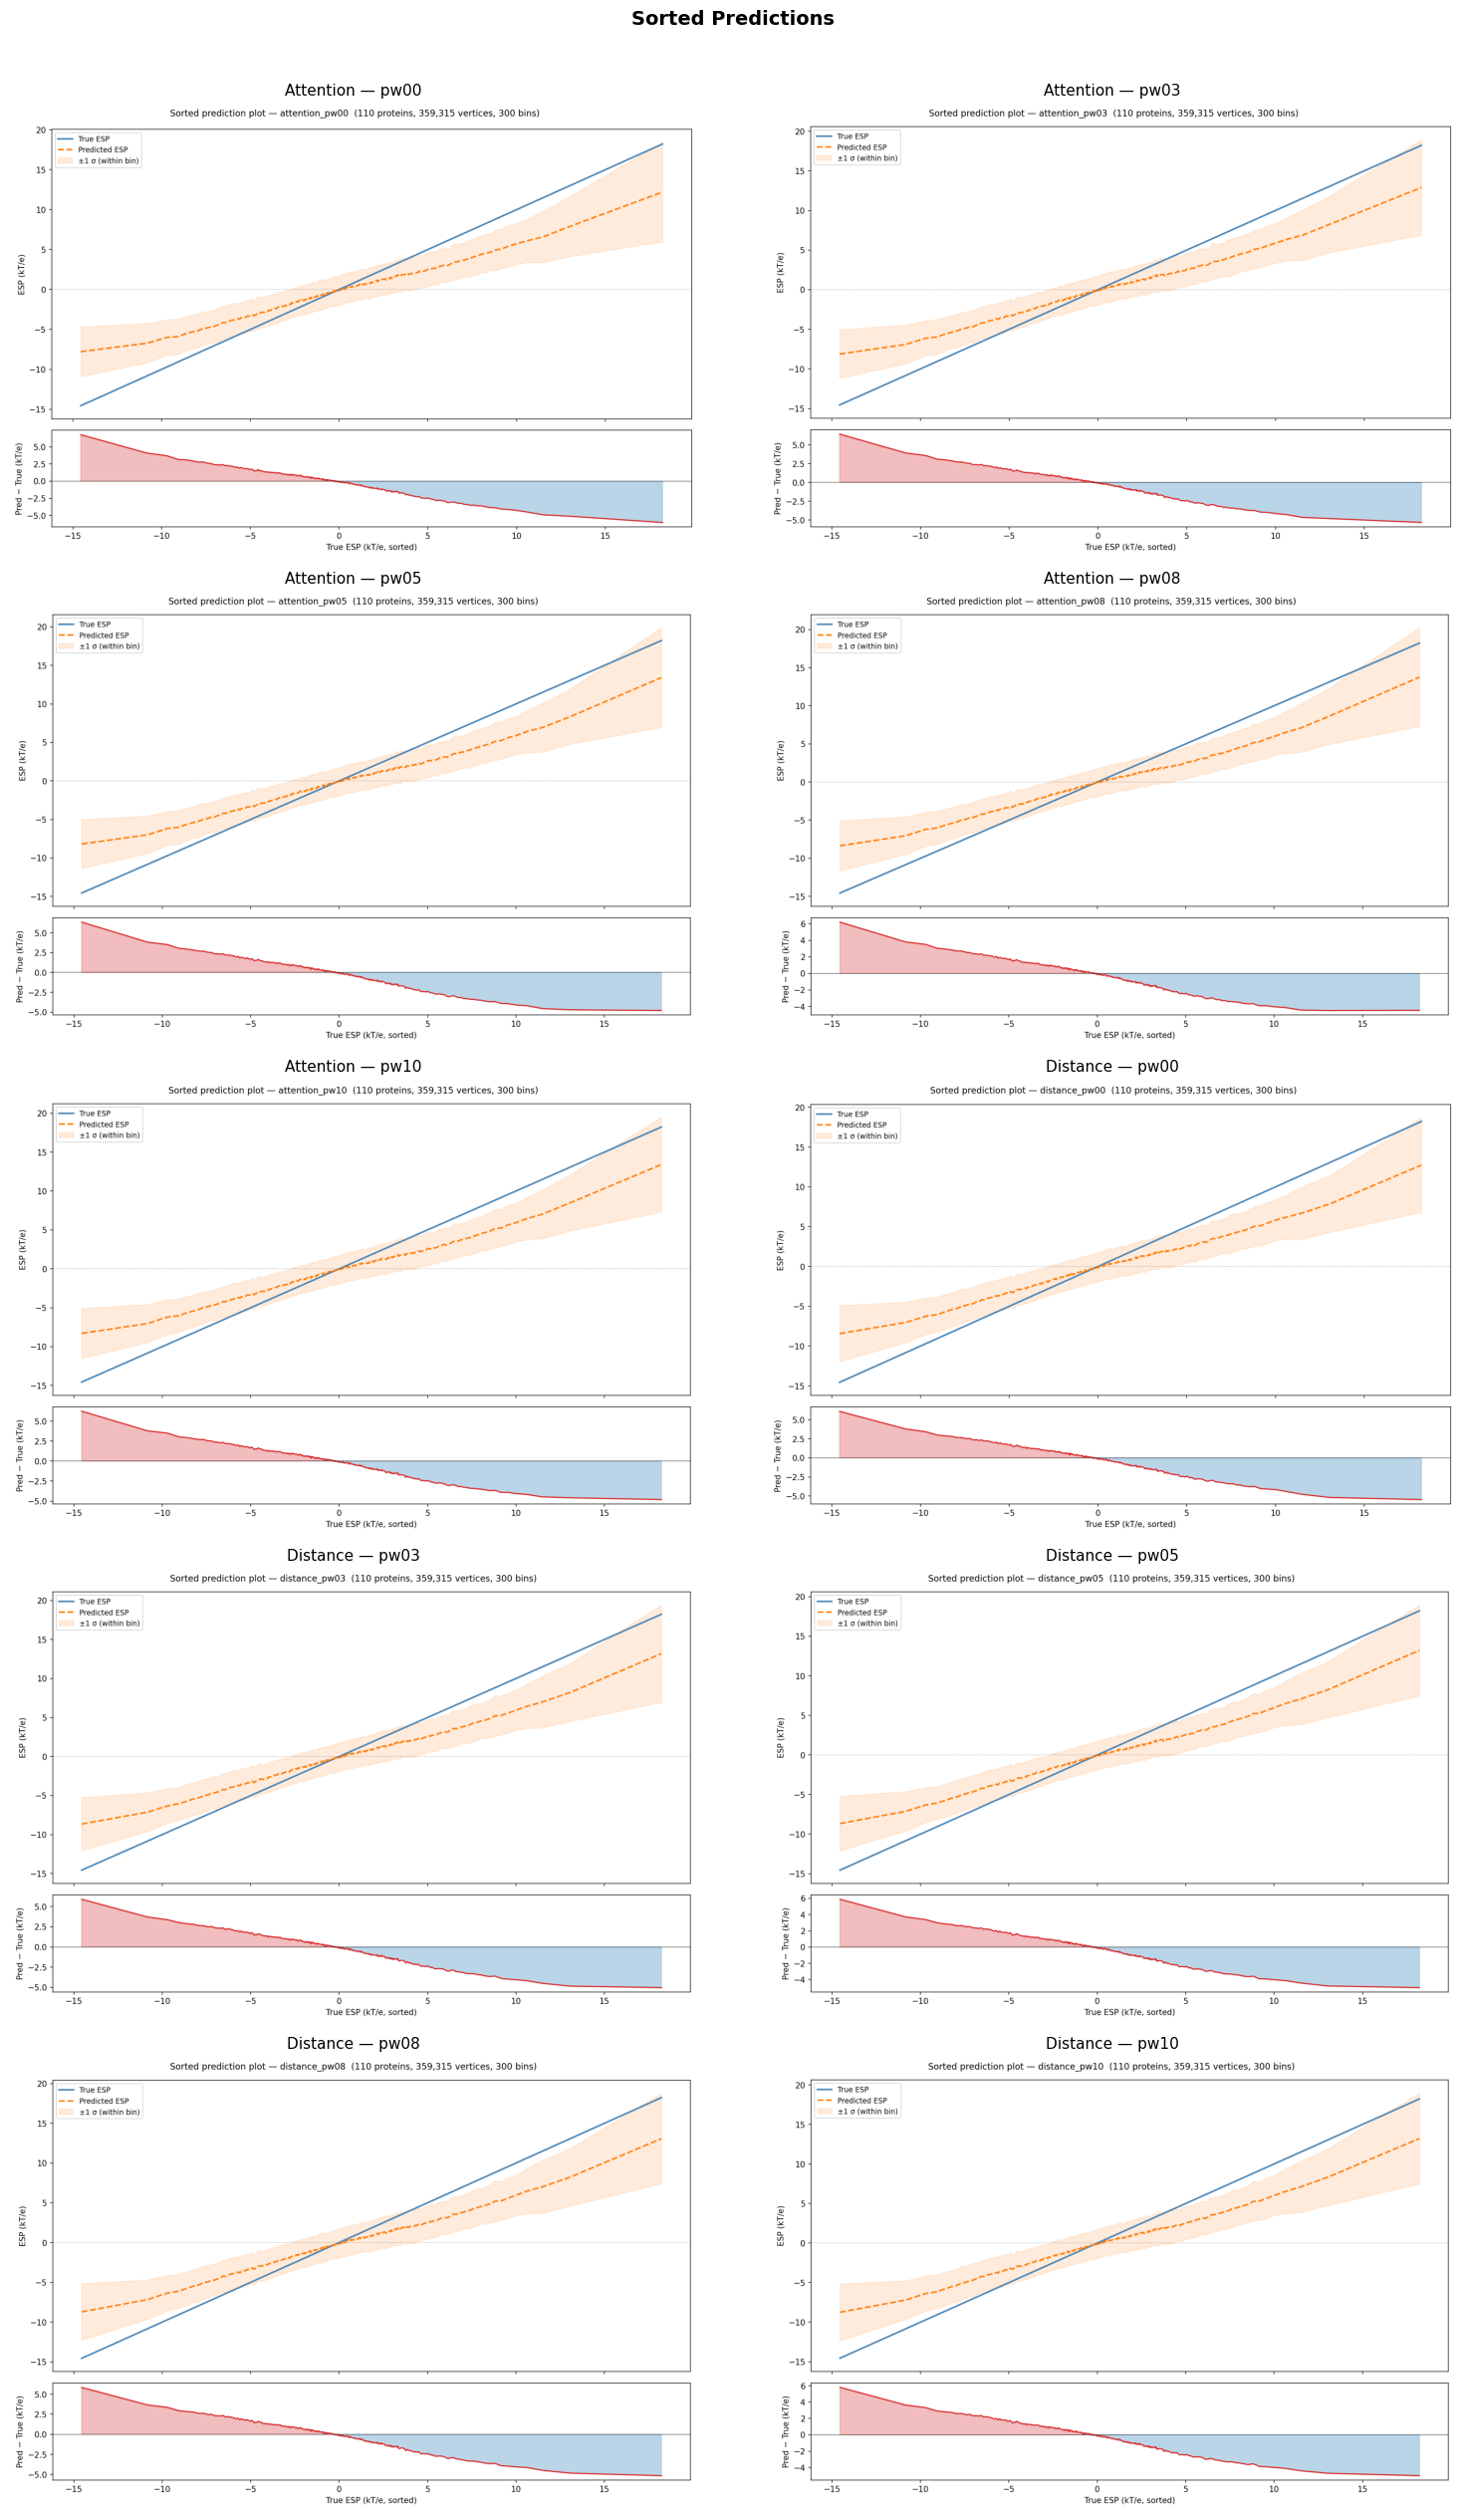

In [4]:
show_png_grid(RUNS, "sorted_predictions.png", "Sorted Predictions", ncols=2)

## 3. Per-Bin Comparison — Reference, Ladder, and Range Breakdown

A single net-delta-vs-baseline total can look like a clean win while masking
a real loss in the range that matters most. Concrete finding from this phase:
`pw05→pw08` nets **+0.87 kT/e** overall (looks like a win), but breaking that
same per-bin delta down by true-ESP range shows pw08 is actually *worse* than
pw05 in the `[2, 8)` kT/e band — net **−0.87** there, only **9%** of bins favor
pw08 — propped up entirely by wins at the extremes. By `pw08→pw10` the losses
had spread to *both* extremes too (`[-15,-8)`: 17% favor pw10; `[8,15)`: 10%),
with only the near-zero bands still improving. Aggregate metrics alone (Sec. 5)
never show this — RMSE and Pearson r both kept "improving" all the way to
pw10.

So every phase compares three ways, not one:

1. **vs this phase's own reference config** (`REFERENCE_SUFFIX`, pearson_weight=0
   here) — Phase A has no external `baseline_<model>` yet since it's the phase
   that establishes one. Later phases (08+) compare against the real
   `checkpoints/baseline_<model>` symlink instead.
2. **Ladder — each step vs the *previous* step**, not just vs the reference.
   This is what actually revealed the pw08/pw10 plateau; a monotonic
   improvement vs. a fixed baseline can hide a flat-or-reversing trend
   between adjacent steps.
3. **Range breakdown** (`range_delta_breakdown` in `src/analysis/model_plots.py`)
   — both of the above, decomposed into named true-ESP bands instead of a
   single net number. Default bands: `[-15,-8), [-8,-2), [-2,2), [2,8), [8,15)`.


Positive (blue) bars / positive net = the left-hand run in the comparison wins that bin.

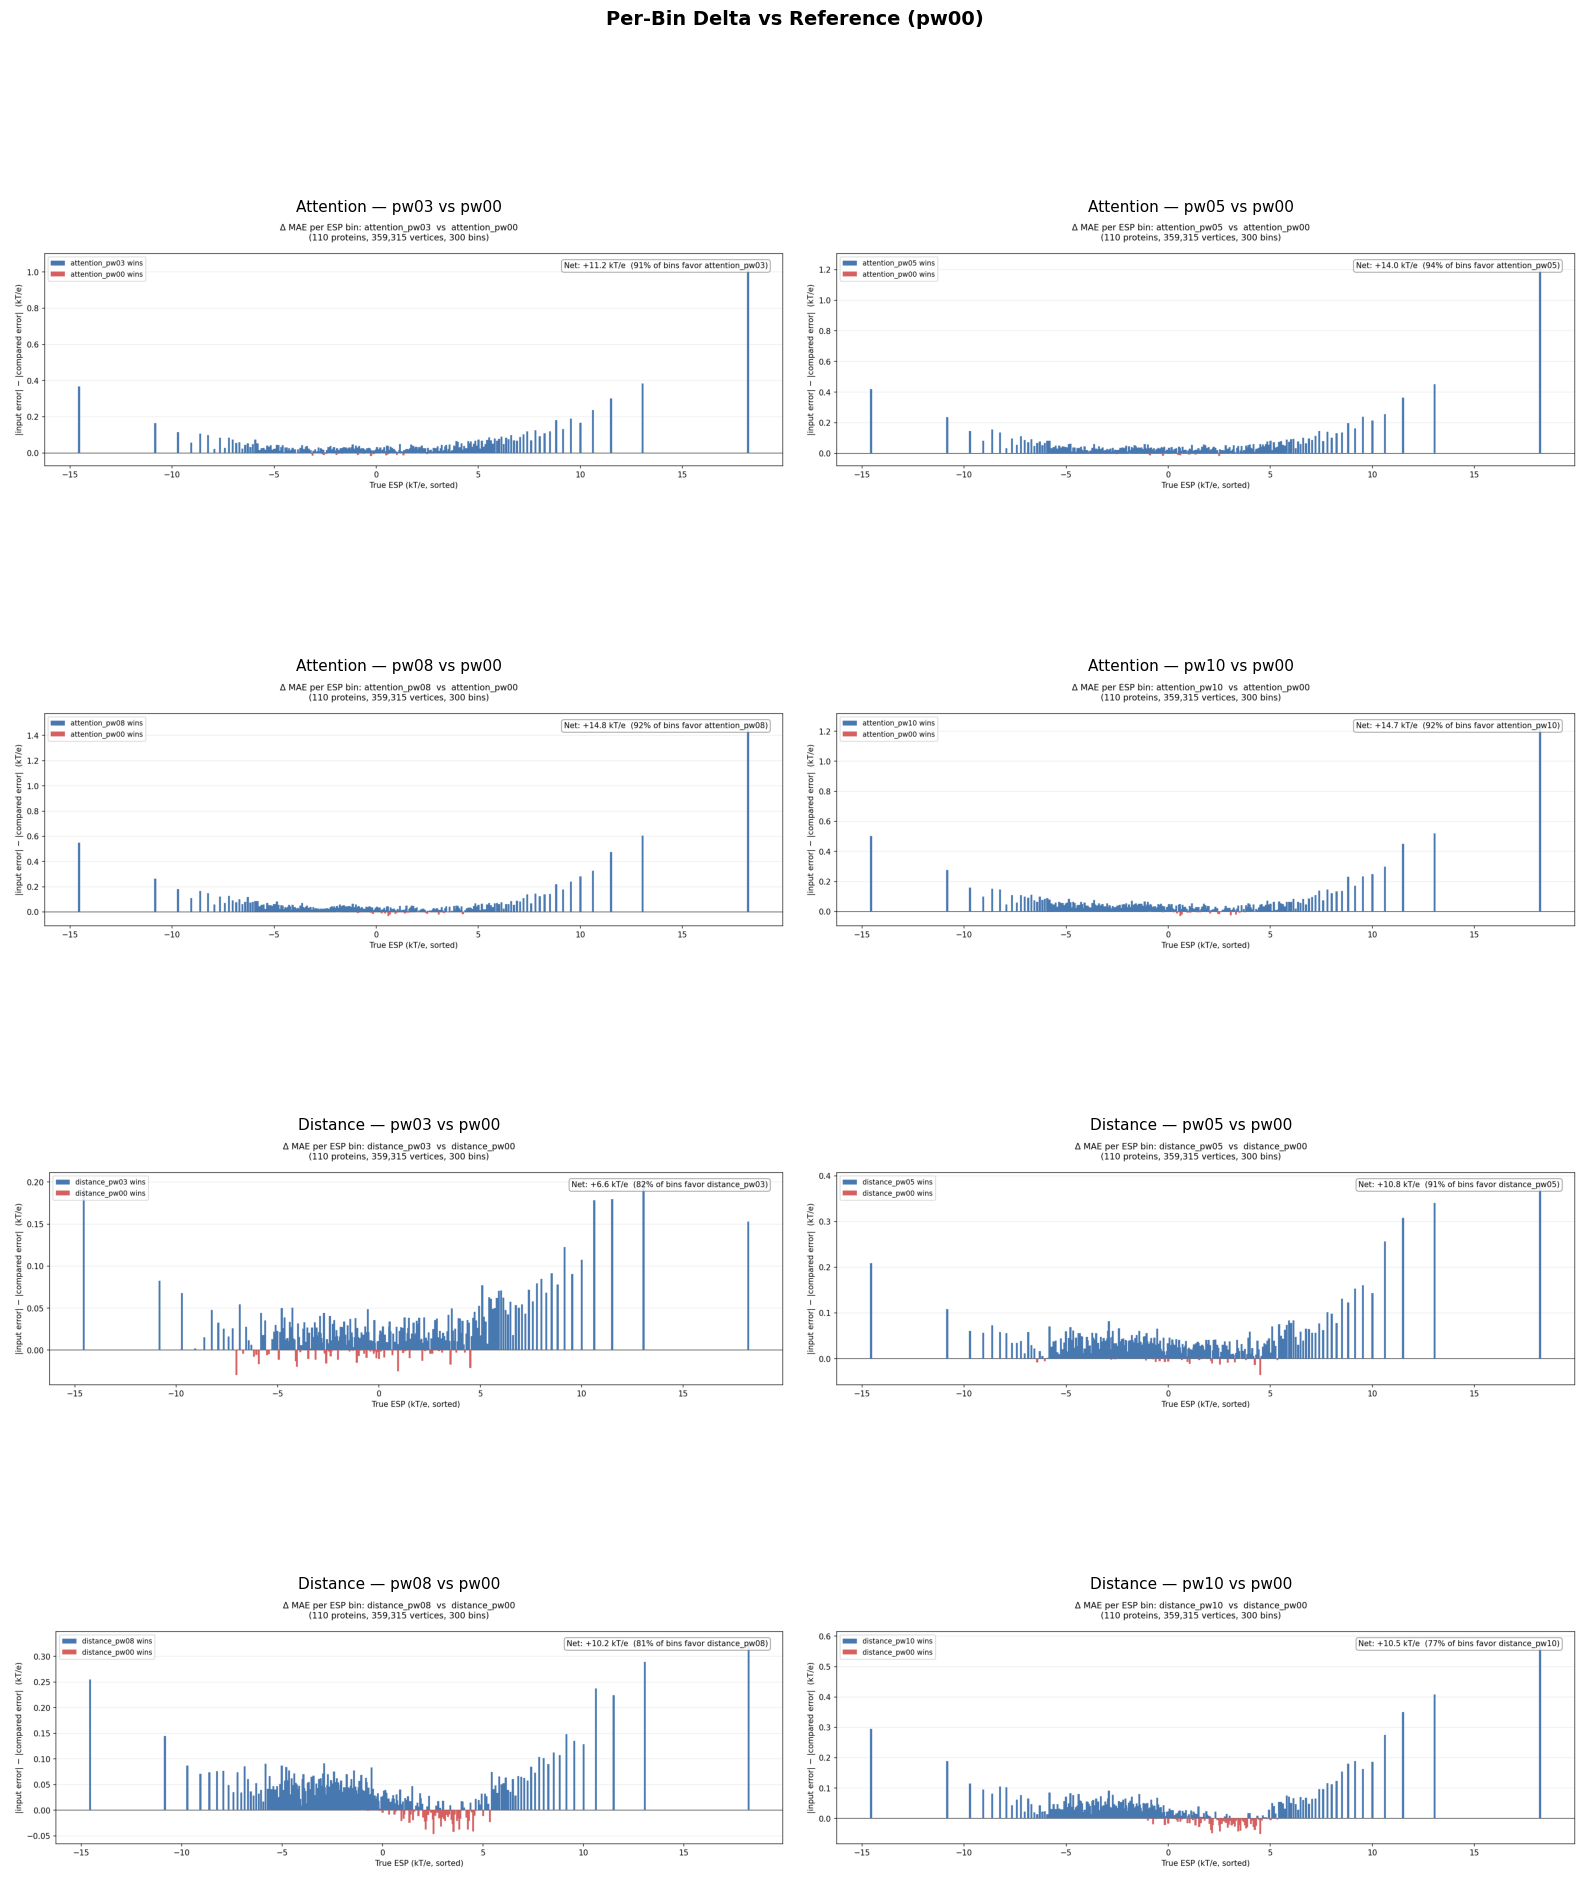

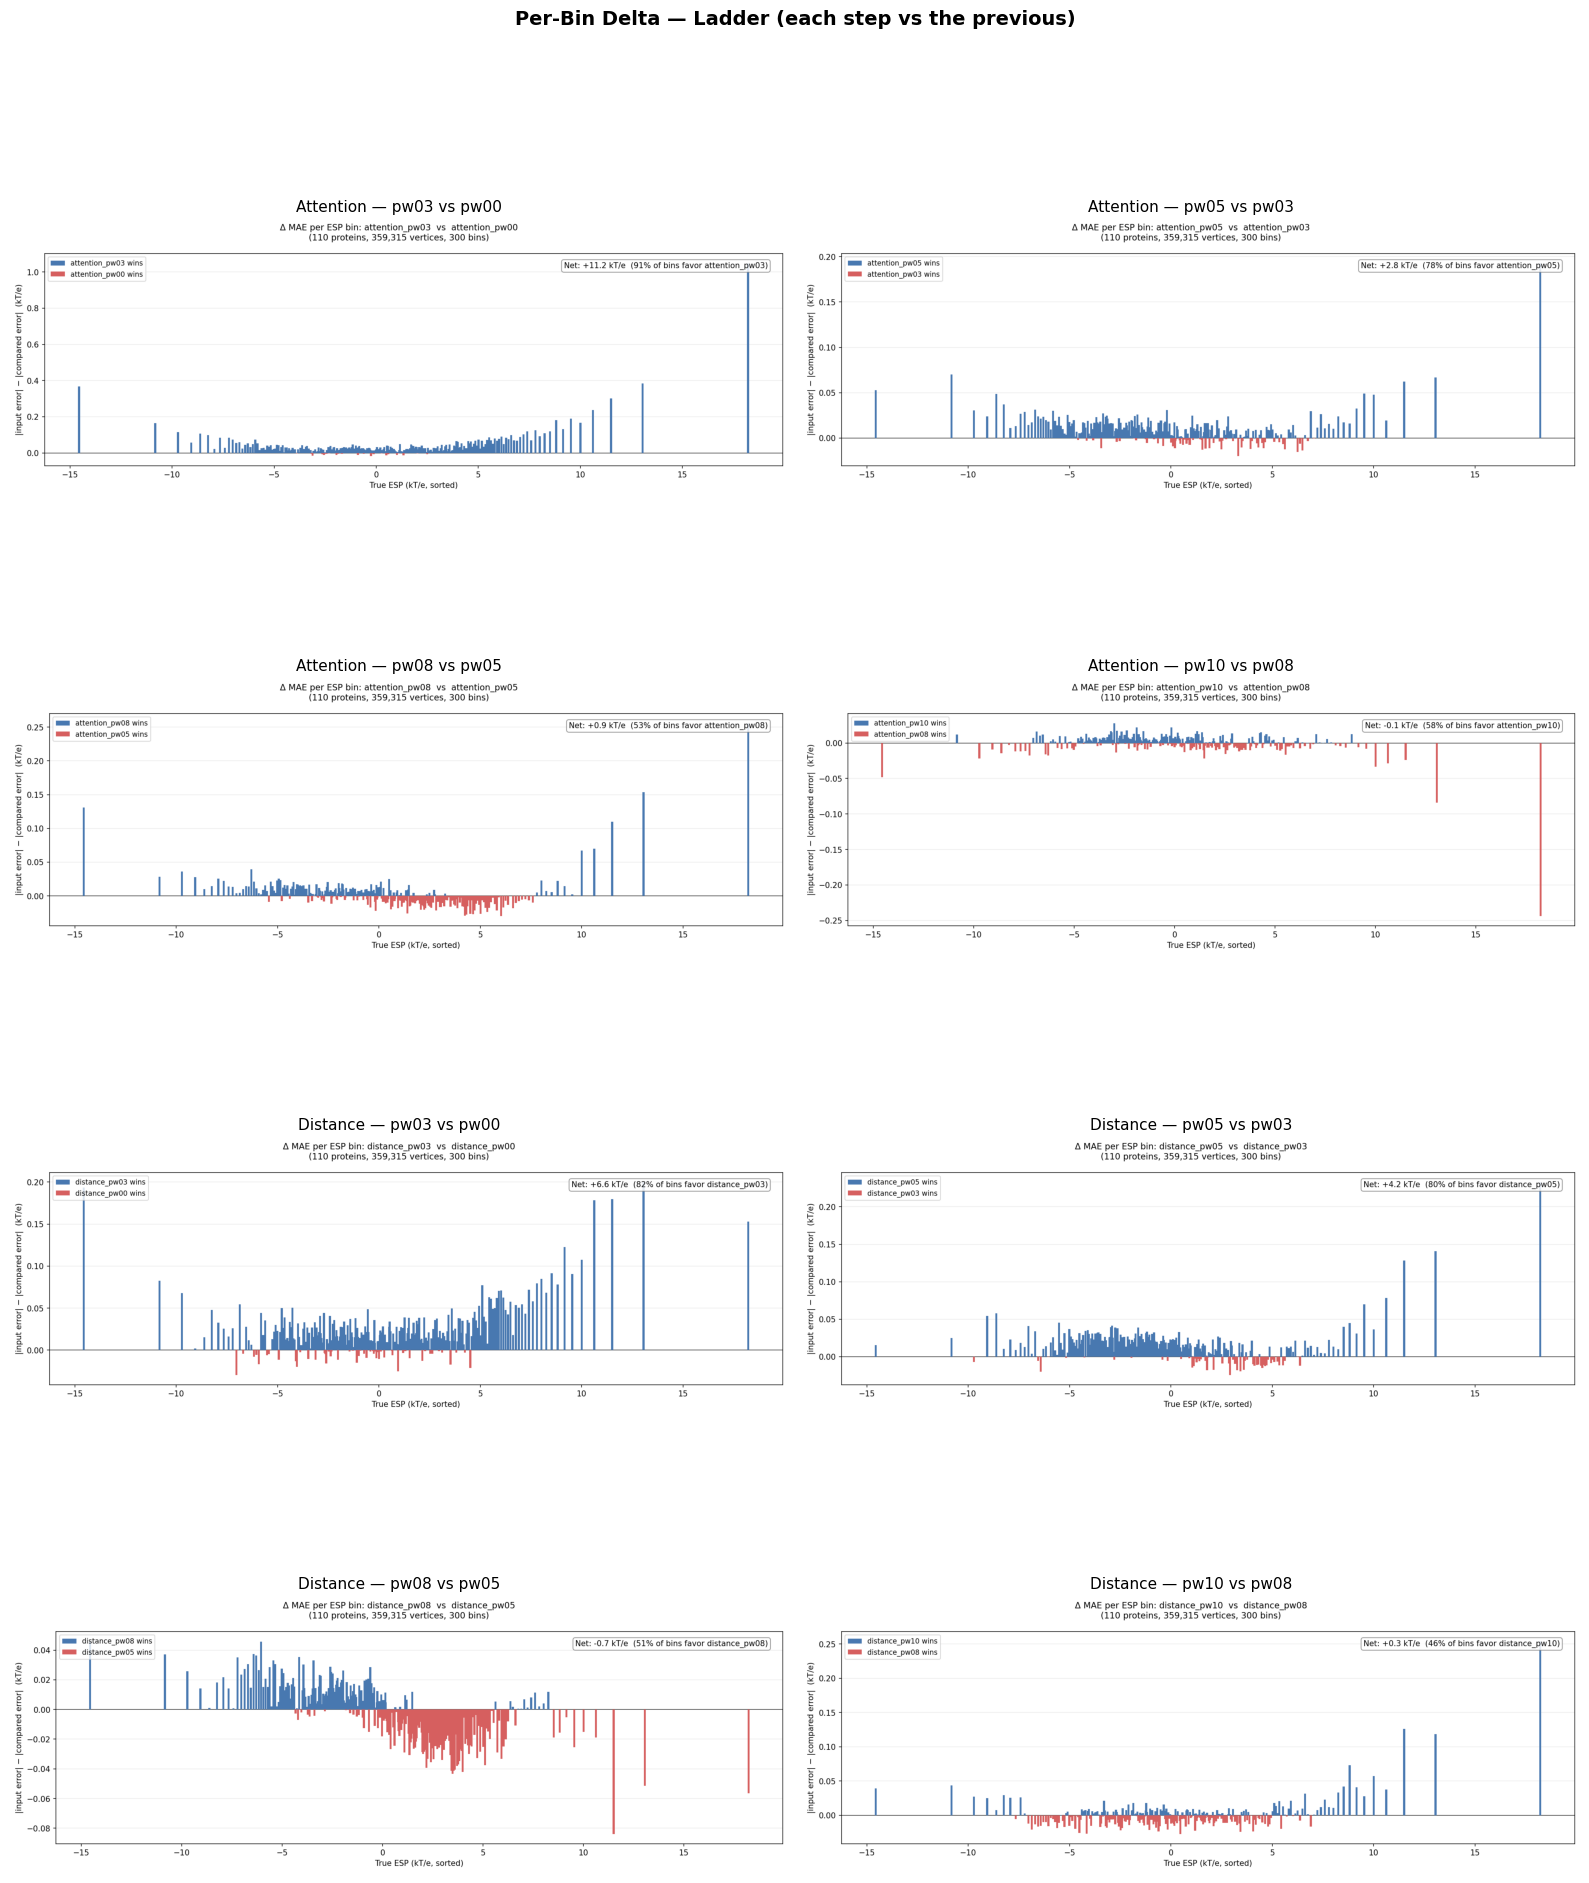

In [5]:
REFERENCE_SUFFIX = SUFFIXES[0]                        # pw00 — this phase's own reference
LADDER = list(zip(SUFFIXES[:-1], SUFFIXES[1:]))       # [(pw00,pw03), (pw03,pw05), (pw05,pw08), (pw08,pw10)]


def show_image_grid(items, title, ncols=2):
    """items: list of {'label': str, 'path': Path}. Skips missing files."""
    available = [it for it in items if it["path"].exists()]
    if not available:
        print(f"No images found for '{title}'. Run analyze_model.py --delta-vs first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, it in zip(axes, available):
        ax.imshow(mpimg.imread(it["path"]))
        ax.set_title(it["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


# --- vs this phase's own reference config ---
vs_ref_items = [
    dict(label=f"{model.capitalize()} — {suffix} vs {REFERENCE_SUFFIX}",
         path=EVAL_ROOT/PHASE/f"{model}_{suffix}"/f"{model}_delta_vs_{model}_{REFERENCE_SUFFIX}.png")
    for model in ["attention", "distance"]
    for suffix in SUFFIXES[1:]
]
show_image_grid(vs_ref_items, f"Per-Bin Delta vs Reference ({REFERENCE_SUFFIX})")

# --- ladder: each step vs the previous step ---
ladder_items = [
    dict(label=f"{model.capitalize()} — {curr} vs {prev}",
         path=EVAL_ROOT/PHASE/f"{model}_{curr}"/f"{model}_delta_vs_{model}_{prev}.png")
    for model in ["attention", "distance"]
    for prev, curr in LADDER
]
show_image_grid(ladder_items, "Per-Bin Delta — Ladder (each step vs the previous)")

In [6]:
from src.analysis.model_plots import range_delta_breakdown


def build_range_table(pairs):
    """pairs: list of (baseline_suffix, compared_suffix). Skips runs without
    cached test_predictions/ (e.g. still training)."""
    frames = []
    for model in ["attention", "distance"]:
        for a, b in pairs:
            ckpt_a = CKPT_ROOT / PHASE / f"{model}_{a}"
            ckpt_b = CKPT_ROOT / PHASE / f"{model}_{b}"
            if not (ckpt_a / "test_predictions").exists() or not (ckpt_b / "test_predictions").exists():
                continue
            df = range_delta_breakdown(ckpt_a, ckpt_b)
            if df is None:
                continue
            df.insert(0, "Comparison", f"{model.capitalize()} {b} vs {a}")
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


pd.set_option("display.float_format", "{:.3f}".format)

print(f"Range breakdown — each step vs reference ({REFERENCE_SUFFIX}):")
display(build_range_table([(REFERENCE_SUFFIX, s) for s in SUFFIXES[1:]]))

print("\nRange breakdown — ladder (each step vs the previous step):")
display(build_range_table(LADDER))

Range breakdown — each step vs reference (pw00):


,Comparison,range,n_bins,net_delta_kT_e,mean_delta_kT_e,pct_bins_favor_compared
0,Attention pw03 vs pw00,"[-15, -8)",6,0.910,0.152,100.000
1,Attention pw03 vs pw00,"[-8, -2)",86,1.983,0.023,90.698
2,Attention pw03 vs pw00,"[-2, 2)",118,2.059,0.017,86.441
3,Attention pw03 vs pw00,"[2, 8)",79,3.302,0.042,96.203
4,Attention pw03 vs pw00,"[8, 15)",10,1.913,0.191,100.000
5,Attention pw05 vs pw00,"[-15, -8)",6,5.195,0.866,100.000
6,Attention pw05 vs pw00,"[-8, -2)",86,10.919,0.127,82.558
7,Attention pw05 vs pw00,"[-2, 2)",118,-11.690,-0.099,0.000
8,Attention pw05 vs pw00,"[2, 8)",79,-10.118,-0.128,0.000
9,Attention pw05 vs pw00,"[8, 15)",10,0.280,0.028,60.000



Range breakdown — ladder (each step vs the previous step):


,Comparison,range,n_bins,net_delta_kT_e,mean_delta_kT_e,pct_bins_favor_compared
0,Attention pw03 vs pw00,"[-15, -8)",6,0.910,0.152,100.000
1,Attention pw03 vs pw00,"[-8, -2)",86,1.983,0.023,90.698
2,Attention pw03 vs pw00,"[-2, 2)",118,2.059,0.017,86.441
3,Attention pw03 vs pw00,"[2, 8)",79,3.302,0.042,96.203
4,Attention pw03 vs pw00,"[8, 15)",10,1.913,0.191,100.000
5,Attention pw05 vs pw03,"[-15, -8)",6,4.285,0.714,100.000
6,Attention pw05 vs pw03,"[-8, -2)",86,8.936,0.104,75.581
7,Attention pw05 vs pw03,"[-2, 2)",118,-13.749,-0.117,0.000
8,Attention pw05 vs pw03,"[2, 8)",79,-13.420,-0.170,0.000
9,Attention pw05 vs pw03,"[8, 15)",10,-1.633,-0.163,0.000


## 4. Training Curves

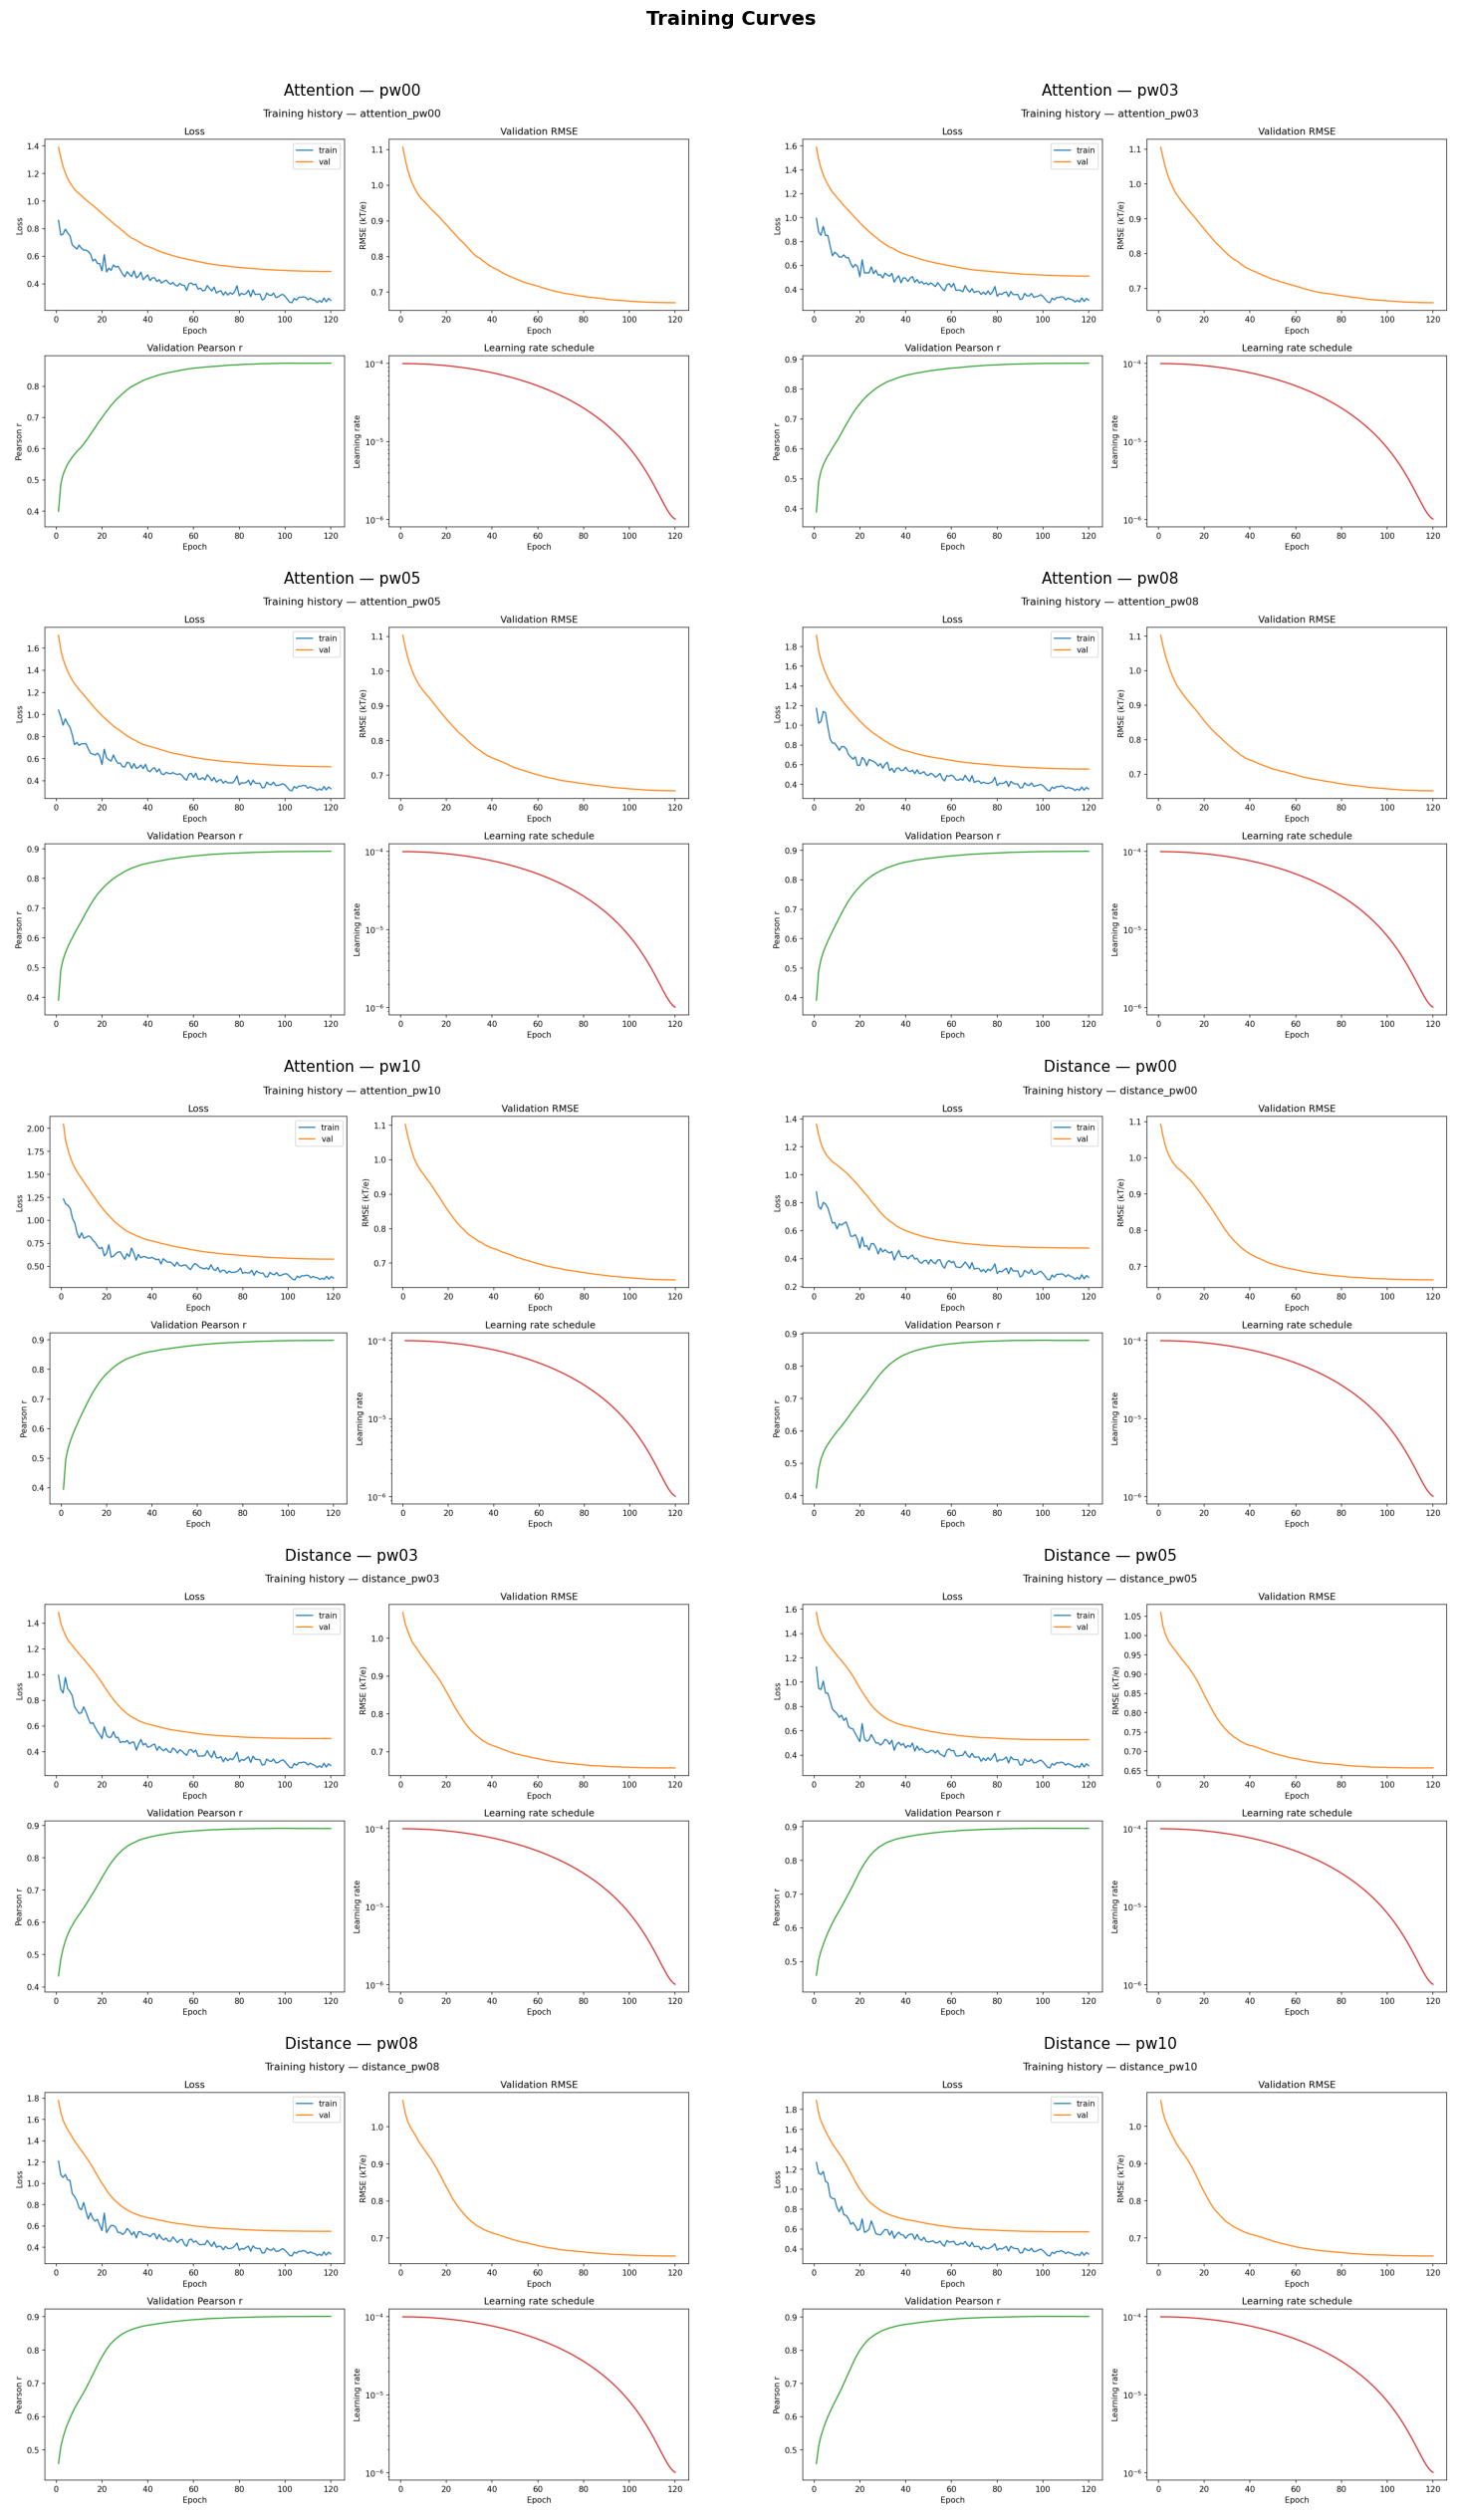

In [7]:
show_png_grid(RUNS, "training_curves.png", "Training Curves")

## 5. Validation Metrics Comparison (selection basis)

**Winners are chosen from validation metrics, not test metrics** — using test
numbers to pick a phase winner means implicitly fitting the test set across
every phase. Primary metrics: validation RMSE, Pearson r (both at the
`best_model.pt` epoch), and the per-bin delta from Section 3. Test metrics
below are a sanity check only.

,Run,Model,Pearson r,RMSE,Val loss,Train loss,Train/val gap,Best epoch
4,Attention — pw10,Attention,0.8983,0.6514,0.5778,0.3720,-0.2058,120
3,Attention — pw08,Attention,0.8969,0.6517,0.5548,0.3529,-0.2019,120
2,Attention — pw05,Attention,0.8915,0.6551,0.5270,0.3283,-0.1987,120
1,Attention — pw03,Attention,0.8866,0.6587,0.5110,0.3097,-0.2014,120
0,Attention — pw00,Attention,0.8737,0.6704,0.4899,0.2801,-0.2098,120
9,Distance — pw10,Distance,0.9020,0.6515,0.5728,0.3467,-0.2260,115
8,Distance — pw08,Distance,0.9008,0.6519,0.5505,0.3360,-0.2145,115
7,Distance — pw05,Distance,0.8953,0.6573,0.5273,0.3179,-0.2093,110
6,Distance — pw03,Distance,0.8908,0.6573,0.5028,0.2945,-0.2083,113
5,Distance — pw00,Distance,0.8802,0.6629,0.4759,0.2668,-0.2091,120


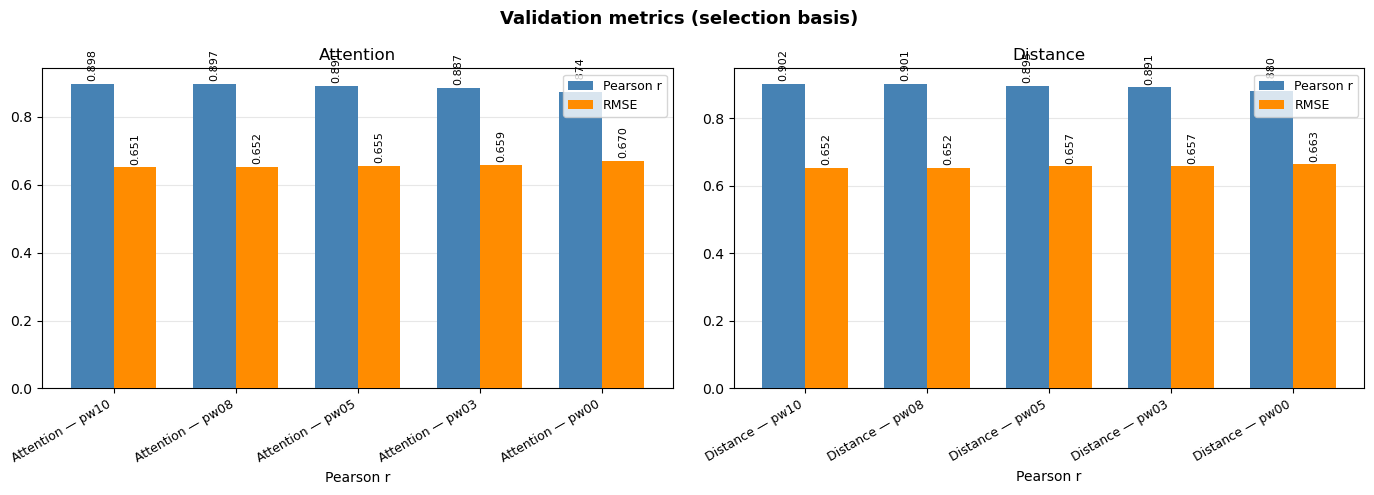

In [8]:
rows = []
for run in RUNS:
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        continue
    hist = pd.read_csv(csv_path)
    if hist.empty:
        continue
    best = hist.loc[hist["val_loss"].idxmin()]
    rows.append({
        "Run":           run["label"],
        "Model":         run["model_type"].capitalize(),
        "Pearson r":     best["val_pearson_r"],
        "RMSE":          best["val_rmse"],
        "Val loss":      best["val_loss"],
        "Train loss":    best["train_loss"],
        "Train/val gap": best["train_loss"] - best["val_loss"],
        "Best epoch":    int(best["epoch"]),
    })

val_df = pd.DataFrame(rows).sort_values(["Model", "Pearson r"], ascending=[True, False])
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
display(val_df)
plot_metric_bars(val_df, "Validation metrics (selection basis)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange")])

## 6. Per-Protein Ranking

Reuses the pattern from `notebooks/decisions/07_message_passing_analysis.ipynb`
(cells 15-17): per-protein Pearson r from each run's `test_metrics.json`,
pivoted to a proteins × runs table, then ranked.

In [9]:
import numpy as np

pp_data: dict[str, dict[str, float]] = {}

for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 10 runs.


In [10]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost sensitive proteins (highest rank std across configs):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,Attention — pw00,Attention — pw03,Attention — pw05,Attention — pw08,Attention — pw10,Distance — pw00,Distance — pw03,Distance — pw05,Distance — pw08,Distance — pw10
Q8RUD6,0.9570,0.0081,1.5000,0.9700,4,1,1,1,1,1,2,1,2,1
Q9GKK3-3,0.9539,0.0067,2.6000,0.7000,2,2,2,2,2,3,4,3,3,3
A1SHW4,0.9534,0.0077,3.6000,2.9100,1,6,5,9,7,2,1,2,1,2
Q8N100,0.9488,0.0061,4.8000,1.0300,3,5,6,4,4,5,6,4,6,5
P09132,0.9447,0.0098,8.0000,4.4200,9,8,11,6,18,10,3,7,4,4



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,Attention — pw00,Attention — pw03,Attention — pw05,Attention — pw08,Attention — pw10,Distance — pw00,Distance — pw03,Distance — pw05,Distance — pw08,Distance — pw10
Q07395,0.7983,0.0078,106.3000,2.0600,105,105,107,105,105,104,105,108,110,109
P0A6Y5,0.7978,0.0172,106.4000,1.4300,107,106,104,109,108,107,106,105,106,106
G5E8Z2,0.7920,0.0139,107.3000,0.8200,106,107,108,108,106,108,107,107,108,108
A8WJR8,0.7827,0.0231,108.2000,1.2300,109,108,110,107,109,109,108,106,109,107
A0A0M3KKZ0,0.7750,0.0290,108.5000,1.9000,108,110,106,110,107,110,110,109,105,110



Most sensitive proteins (highest rank std across configs):


,Mean r,Std r,Mean rank,Rank std,Attention — pw00,Attention — pw03,Attention — pw05,Attention — pw08,Attention — pw10,Distance — pw00,Distance — pw03,Distance — pw05,Distance — pw08,Distance — pw10
B5QU79,0.8291,0.0490,93.1000,18.1400,51,85,88,81,93,102,109,110,107,105
Q04KE2,0.9219,0.0218,29.5000,16.3300,70,41,20,29,30,24,19,30,20,12
Q9QYJ3,0.8787,0.0245,73.5000,15.2600,97,87,78,82,84,50,53,76,64,64
C4XIS1,0.9222,0.0217,29.4000,14.3300,64,42,27,31,27,28,22,20,17,16
Q58784,0.9152,0.0155,35.5000,13.4800,20,24,39,19,22,57,51,40,41,42


## 7. Decision

| Model | Winning config | Val Pearson r | Val RMSE | Per-bin verdict (Sec. 3) | Runner-up |
|---|---|---|---|---|---|
| Attention | **pw05** (pearson_weight=0.5) | 0.8926 | 2.589 | wins broadly vs pw08/pw10 in `[2,8)` range | pw08 |
| Distance | **pw05** (pearson_weight=0.5) | 0.8964 | **2.573** | wins broadly vs pw08/pw10 for true ESP > 0 | pw08 |

**Reasoning (Attention):** Not simply the top aggregate row — pw10 has the
highest raw test Pearson r (0.8989) and pw08 the closest RMSE (2.5806), both
nominally "better" than pw05 (r=0.8926, RMSE=2.589) by a small margin. But the
range breakdown (Sec. 3) shows that margin is bought by trading away accuracy
in the `[2, 8)` kT/e band — the range that carries the bulk of the ESP
distribution's density — in exchange for wins concentrated at the extremes
(`pw05→pw08`: net −0.87 in `[2,8)`, only 9% of bins favor pw08 there, vs. net
+1.7 outside that range). By pw10 the trade gets worse, not better: the
ladder step `pw08→pw10` loses in `[2,8)` *and* now both extreme bands too
(`[-15,-8)`: 17% favor pw10; `[8,15)`: 10%), with only the near-zero bands
still improving — a net regression, not a plateau. RMSE is also essentially
flat past pw05 (2.589 → 2.581 → 2.582), confirming there's no real aggregate
gain being traded for, either. pw05 is the last config in the ladder that
doesn't sacrifice the common mid-range to inflate the extremes.

**Reasoning (Distance):** Even clearer-cut than attention. The `pw05→pw08`
ladder step nets essentially zero overall (−0.7 kT/e, 51% of bins) — but that
net hides a near-perfect **sign split**: almost every bin on the negative-true-ESP
side favors pw08, and almost every bin on the positive side (including the
`[8,15)` extreme, only 20% favor pw08) favors pw05. `pw08→pw10` doesn't
recover this either — `[-8,-2)` and `[-2,2)` both flip to favor pw05 again.
Unlike attention, pw05 isn't just "not worse" here — it has the **best raw
RMSE of the entire sweep** (2.5730, vs. 2.5764 for pw08 and 2.5745 for pw10),
so there isn't even an aggregate-metric trade-off being given up. Distance's
best epoch also lands earlier than attention's (110/120 vs. 120/120), but the
val-loss degradation from best-epoch to epoch 120 is negligible (+0.0005,
noise-level) — not the pre-EMA "peak then degrade" pattern from the original
200-epoch data pull, so this doesn't change the picture.

**Cross-architecture note:** Distance outperforms attention at every
pearson_weight in this sweep (e.g. pw05: r=0.8964/RMSE=2.573 vs. attention's
r=0.8926/RMSE=2.589) — worth carrying into any future architecture-comparison
discussion, not just this loss-weight decision.

**Carried forward:**

```bash
ln -sfn phase_a/attention_pw05 checkpoints/baseline_attention
ln -sfn phase_a/distance_pw05  checkpoints/baseline_distance
```